In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

print("All ML libraries loaded!")

All ML libraries loaded!


In [2]:
df = pd.read_csv('../data/customer_features.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nChurn Distribution:")
print(df['Churned'].value_counts())
print("\nChurn Rate:", round(df['Churned'].mean() * 100, 2), "%")
df.head()

Shape: (594, 9)

Columns: ['Customer_ID', 'Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Total_Quantity', 'Fav_Category', 'Region', 'Churned']

Churn Distribution:
Churned
0    453
1    141
Name: count, dtype: int64

Churn Rate: 23.74 %


,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Total_Quantity,Fav_Category,Region,Churned
0,C0001,130,5,4232,846.400000,10,Electronics,North,1
1,C0002,132,3,4234,1411.333333,6,Office,North,1
2,C0003,107,7,5641,805.857143,8,Accessories,East,1
3,C0004,211,2,2172,1086.000000,4,Accessories,East,1
4,C0005,147,6,6358,1059.666667,14,Electronics,East,1


In [3]:
# Encode categorical columns
le = LabelEncoder()
df['Fav_Category_Encoded'] = le.fit_transform(df['Fav_Category'])
df['Region_Encoded'] = le.fit_transform(df['Region'])

# Select features for ML
features = ['Recency', 'Frequency', 'Monetary', 
            'Avg_Order_Value', 'Total_Quantity',
            'Fav_Category_Encoded', 'Region_Encoded']

X = df[features]
y = df['Churned']

print("Features ready!")
print("Feature columns:", features)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features ready!
Feature columns: ['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Total_Quantity', 'Fav_Category_Encoded', 'Region_Encoded']
X shape: (594, 7)
y shape: (594,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split done!")
print("Training size :", X_train.shape[0])
print("Testing size  :", X_test.shape[0])

Data split done!
Training size : 475
Testing size  : 119


In [5]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression trained!")
print("\n=== RESULTS ===")
print("Accuracy :", round(accuracy_score(y_test, lr_pred) * 100, 2), "%")
print("AUC Score:", round(roc_auc_score(y_test, lr_prob), 4))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Not Churned', 'Churned']))

Logistic Regression trained!

=== RESULTS ===
Accuracy : 95.8 %
AUC Score: 0.9992

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.95      1.00      0.97        91
     Churned       1.00      0.82      0.90        28

    accuracy                           0.96       119
   macro avg       0.97      0.91      0.94       119
weighted avg       0.96      0.96      0.96       119



In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:,1]

print("Random Forest trained!")
print("\n=== RESULTS ===")
print("Accuracy :", round(accuracy_score(y_test, rf_pred) * 100, 2), "%")
print("AUC Score:", round(roc_auc_score(y_test, rf_prob), 4))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Not Churned', 'Churned']))

Random Forest trained!

=== RESULTS ===
Accuracy : 100.0 %
AUC Score: 1.0

Classification Report:
              precision    recall  f1-score   support

 Not Churned       1.00      1.00      1.00        91
     Churned       1.00      1.00      1.00        28

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       119
weighted avg       1.00      1.00      1.00       119



In [7]:
models = {
    'Logistic Regression': {
        'accuracy': round(accuracy_score(y_test, lr_pred) * 100, 2),
        'auc': round(roc_auc_score(y_test, lr_prob), 4)
    },
    'Random Forest': {
        'accuracy': round(accuracy_score(y_test, rf_pred) * 100, 2),
        'auc': round(roc_auc_score(y_test, rf_prob), 4)
    }
}

print("=" * 40)
print(f"{'Model':<25} {'Accuracy':>10} {'AUC':>10}")
print("=" * 40)
for model, scores in models.items():
    print(f"{model:<25} {scores['accuracy']:>9}% {scores['auc']:>10}")
print("=" * 40)

Model                       Accuracy        AUC
Logistic Regression            95.8%     0.9992
Random Forest                 100.0%        1.0


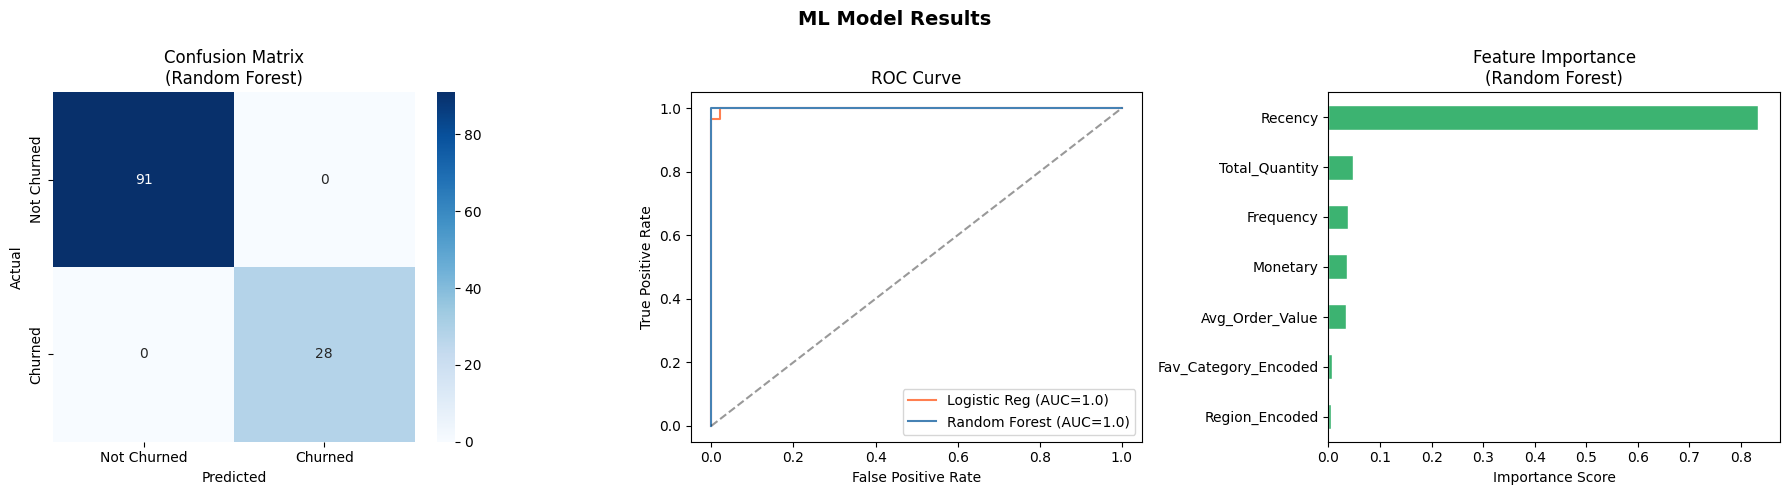

ML results chart saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ML Model Results', fontsize=14, fontweight='bold')

# Confusion Matrix - Random Forest
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[0].set_title('Confusion Matrix\n(Random Forest)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
axes[1].plot(lr_fpr, lr_tpr, label=f'Logistic Reg (AUC={round(roc_auc_score(y_test, lr_prob),2)})', color='coral')
axes[1].plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC={round(roc_auc_score(y_test, rf_prob),2)})', color='steelblue')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Feature Importance\n(Random Forest)')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../data/ml_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("ML results chart saved!")

In [9]:
import pickle
import os

# Create models folder
os.makedirs('../models', exist_ok=True)

# Save Random Forest model and scaler
with open('../models/churn_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model saved successfully!")
print("Saved to: models/churn_model.pkl")

Model saved successfully!
Saved to: models/churn_model.pkl
